<a href="https://colab.research.google.com/github/Anshubhardwaj2005/learninghub/blob/main/EDA_NYC_Taxi_Analysis_Anshu_Bhardwaj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
# Task 1: Import Required Libraries
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

sns.set_style("whitegrid")

In [121]:
# Task 2: Verify NYC Taxi Data Files
trip_path = "trip_records"

files = sorted(
    [f for f in os.listdir(trip_path)
     if f.endswith(".parquet")]
)

print("Total Files:", len(files))

for file in files:
    print(file)

Total Files: 12
yellow_tripdata_2023-01.parquet
yellow_tripdata_2023-02.parquet
yellow_tripdata_2023-03.parquet
yellow_tripdata_2023-04.parquet
yellow_tripdata_2023-05.parquet
yellow_tripdata_2023-06.parquet
yellow_tripdata_2023-07.parquet
yellow_tripdata_2023-08.parquet
yellow_tripdata_2023-09.parquet
yellow_tripdata_2023-10.parquet
yellow_tripdata_2023-11.parquet
yellow_tripdata_2023-12.parquet


In [122]:
# Task 3: Load Taxi Zone Shapefile
zones = gpd.read_file(
    "taxi_zones/taxi_zones.shp"
)

print(zones.shape)

zones.head()

(263, 7)


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [123]:
# Task 4: Load and Sample 2023 Taxi Data
sample_list = []

for file in files:

    temp_df = pd.read_parquet(
        os.path.join(trip_path, file)
    )

    sample_df = temp_df.sample(
        frac=0.02,
        random_state=42
    )

    sample_list.append(sample_df)

final_df = pd.concat(
    sample_list,
    ignore_index=True
)

print(final_df.shape)

(766203, 20)


In [124]:
# Task 5: Save Sample Dataset
print(final_df.shape)
final_df.to_parquet(
    "output/sampled_nyc_taxi_2023.parquet",
    index=False
)

print("File Saved Successfully")
import os

print(os.listdir("output"))
df = pd.read_parquet(
    "output/sampled_nyc_taxi_2023.parquet"
)

print(df.shape)
df.head()

(766203, 20)
File Saved Successfully
['sampled_nyc_taxi_2023.parquet', 'final_nyc_taxi_analysis.parquet', 'cleaned_nyc_taxi_2023.parquet']
(766203, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,7.2,0.0,0.5,0.00,0.0,1.0,11.20,2.5,0.0,NaN
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,6.5,2.5,0.5,0.00,0.0,1.0,10.50,2.5,0.0,NaN
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,7.9,0.0,0.5,2.38,0.0,1.0,14.28,2.5,0.0,NaN
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,16.3,2.5,0.5,1.50,0.0,1.0,24.30,2.5,0.0,NaN
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,6.5,1.0,0.5,2.30,0.0,1.0,13.80,2.5,0.0,NaN


In [125]:
# Task 6: Initial Data Inspection
df.info()
df.columns.tolist()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766203 entries, 0 to 766202
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               766203 non-null  int64         
 1   tpep_pickup_datetime   766203 non-null  datetime64[us]
 2   tpep_dropoff_datetime  766203 non-null  datetime64[us]
 3   passenger_count        740006 non-null  float64       
 4   trip_distance          766203 non-null  float64       
 5   RatecodeID             740006 non-null  float64       
 6   store_and_fwd_flag     740006 non-null  object        
 7   PULocationID           766203 non-null  int64         
 8   DOLocationID           766203 non-null  int64         
 9   payment_type           766203 non-null  int64         
 10  fare_amount            766203 non-null  float64       
 11  extra                  766203 non-null  float64       
 12  mta_tax                766203 non-null  floa

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
count,766203.000000,766203,766203,740006.000000,766203.000000,740006.000000,766203.000000,766203.000000,766203.000000,766203.000000,766203.000000,766203.000000,766203.000000,766203.000000,766203.000000,766203.000000,740006.000000,59952.000000,680054.000000
mean,1.738897,2023-07-02 23:15:02.554210,2023-07-02 23:32:31.683345,1.370428,3.718939,1.645800,165.248330,163.794267,1.184321,19.513520,1.556969,0.485538,3.527873,0.590028,0.979332,28.459212,2.263764,0.107294,0.143015
min,1.000000,2008-12-31 23:03:12,2009-01-01 13:50:40,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,-500.000000,-7.500000,-0.500000,-79.550000,-65.000000,-1.000000,-503.500000,-2.500000,-1.250000,-1.750000
25%,1.000000,2023-04-02 18:35:42.500000,2023-04-02 18:55:08.500000,1.000000,1.040000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.950000,2.500000,0.000000,0.000000
50%,2.000000,2023-06-27 18:35:47,2023-06-27 18:53:49,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.800000,0.000000,1.000000,21.000000,2.500000,0.000000,0.000000
75%,2.000000,2023-10-06 22:36:09,2023-10-06 22:53:52.500000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.420000,0.000000,1.000000,30.800000,2.500000,0.000000,0.000000
max,6.000000,2023-12-31 23:58:12,2024-01-01 15:28:47,9.000000,33496.830000,99.000000,265.000000,265.000000,4.000000,910.000000,16.500000,4.000000,300.000000,170.750000,1.000000,911.000000,2.500000,1.250000,1.750000
std,0.443906,NaN,NaN,0.892854,72.833921,7.449356,63.966246,69.902880,0.556049,18.893435,1.842115,0.108896,4.097031,2.208907,0.199788,23.637735,0.798403,0.355473,0.477201


In [126]:
# Task 7: Data Cleaning Code Cell 1 – Check Missing Values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]



,0
passenger_count,26197
RatecodeID,26197
store_and_fwd_flag,26197
congestion_surcharge,26197
airport_fee,706251
Airport_fee,86149


In [127]:
# Task 7: Data Cleaning Code Cell 2 – Check Missing Values
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [128]:
# Task 7: Data Cleaning Code Cell 3 – Check Missing Values
df = df.drop_duplicates()

print(df.shape)


(766203, 20)


In [129]:
# Task 7: Data Cleaning Code Cell 4 – Check Negative Monetary Values
monetary_cols = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount"
]

for col in monetary_cols:
    print(col, (df[col] < 0).sum())


fare_amount 7700
extra 3895
mta_tax 7370
tip_amount 46
tolls_amount 481
improvement_surcharge 7590
total_amount 7593


In [130]:
# Task 7: Data Cleaning Code Cell 5 – Remove Negative Total Amounts
df = df[df["total_amount"] >= 0]

print(df.shape)


(758610, 20)


In [131]:
# Task 8: Feature Engineering
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()

df["pickup_month"] = df["tpep_pickup_datetime"].dt.month_name()

df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday

df["trip_duration"] = (
    df["tpep_dropoff_datetime"]
    - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["is_weekend"] = (
    df["pickup_weekday"] >= 5
)

print(df.shape)

df.head()

(758610, 27)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,airport_fee,Airport_fee,pickup_date,pickup_hour,pickup_day,pickup_month,pickup_weekday,trip_duration,is_weekend
0,2,2023-01-29 17:52:02,2023-01-29 17:56:43,1.0,1.17,1.0,N,262,74,2,...,2.5,0.0,NaN,2023-01-29,17,Sunday,January,6,4.683333,True
1,1,2023-01-08 15:57:24,2023-01-08 16:02:47,1.0,0.90,1.0,N,229,237,2,...,2.5,0.0,NaN,2023-01-08,15,Sunday,January,6,5.383333,True
2,2,2023-01-21 19:38:01,2023-01-21 19:45:02,1.0,0.95,1.0,N,45,261,1,...,2.5,0.0,NaN,2023-01-21,19,Saturday,January,5,7.016667,True
3,2,2023-01-23 16:07:31,2023-01-23 16:26:46,5.0,0.88,1.0,N,237,141,1,...,2.5,0.0,NaN,2023-01-23,16,Monday,January,0,19.250000,False
4,2,2023-01-26 21:21:08,2023-01-26 21:24:48,2.0,1.03,1.0,N,229,140,1,...,2.5,0.0,NaN,2023-01-26,21,Thursday,January,3,3.666667,False


In [132]:
df.info()
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
Index: 758610 entries, 0 to 766202
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               758610 non-null  int64         
 1   tpep_pickup_datetime   758610 non-null  datetime64[us]
 2   tpep_dropoff_datetime  758610 non-null  datetime64[us]
 3   passenger_count        732416 non-null  float64       
 4   trip_distance          758610 non-null  float64       
 5   RatecodeID             732416 non-null  float64       
 6   store_and_fwd_flag     732416 non-null  object        
 7   PULocationID           758610 non-null  int64         
 8   DOLocationID           758610 non-null  int64         
 9   payment_type           758610 non-null  int64         
 10  fare_amount            758610 non-null  float64       
 11  extra                  758610 non-null  float64       
 12  mta_tax                758610 non-null  float64  

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'Airport_fee',
 'pickup_date',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_weekday',
 'trip_duration',
 'is_weekend']

In [133]:
#Task 7A: Fix Airport Fee Columns
# Combine airport_fee and Airport_fee

df["airport_fee"] = (
    df["airport_fee"]
    .fillna(df["Airport_fee"])
)

# Drop duplicate column

df.drop(
    columns=["Airport_fee"],
    inplace=True
)

print(df["airport_fee"].isnull().sum())


26194


In [134]:
#Continue with Task 7B

df["passenger_count"] = (
    df["passenger_count"]
    .fillna(df["passenger_count"].median())
)

df["RatecodeID"] = (
    df["RatecodeID"]
    .fillna(1)
)

df["store_and_fwd_flag"] = (
    df["store_and_fwd_flag"]
    .fillna("N")
)

df["congestion_surcharge"] = (
    df["congestion_surcharge"]
    .fillna(0)
)

df["airport_fee"] = (
    df["airport_fee"]
    .fillna(0)
)

In [135]:
#verify task 7B
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [136]:
## Task 7C: Save Cleaned Dataset

df.to_parquet(
    "output/cleaned_nyc_taxi_2023.parquet",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [137]:
#Verify

print(df.shape)

df.info()
df.isnull().sum()

(758610, 26)
<class 'pandas.core.frame.DataFrame'>
Index: 758610 entries, 0 to 766202
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               758610 non-null  int64         
 1   tpep_pickup_datetime   758610 non-null  datetime64[us]
 2   tpep_dropoff_datetime  758610 non-null  datetime64[us]
 3   passenger_count        758610 non-null  float64       
 4   trip_distance          758610 non-null  float64       
 5   RatecodeID             758610 non-null  float64       
 6   store_and_fwd_flag     758610 non-null  object        
 7   PULocationID           758610 non-null  int64         
 8   DOLocationID           758610 non-null  int64         
 9   payment_type           758610 non-null  int64         
 10  fare_amount            758610 non-null  float64       
 11  extra                  758610 non-null  float64       
 12  mta_tax                758610 non-nu

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [138]:
# Task 8: Save Cleaned Dataset
df.to_parquet(
    "output/cleaned_nyc_taxi_2023.parquet",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


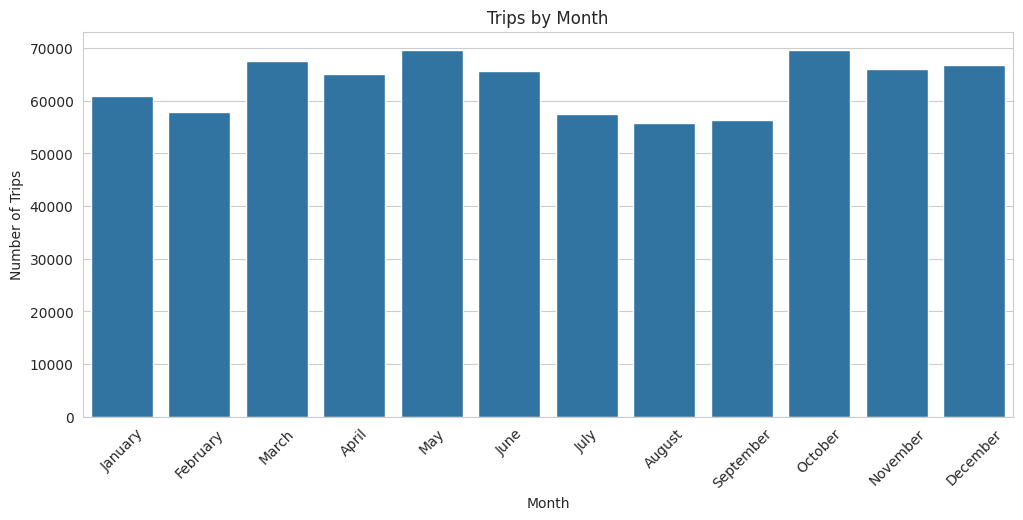

In [139]:
# Task 9: Monthly Trip Analysis

monthly_trips = (
    df.groupby("pickup_month")
      .size()
      .reset_index(name="trip_count")
)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_trips["pickup_month"] = pd.Categorical(
    monthly_trips["pickup_month"],
    categories=month_order,
    ordered=True
)

monthly_trips = monthly_trips.sort_values("pickup_month")

plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_trips,
    x="pickup_month",
    y="trip_count"
)

plt.xticks(rotation=45)

plt.title("Trips by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")

plt.show()

#The monthly trip distribution shows relatively stable demand throughout the year. Trip volume peaks in May and October, indicating periods of increased taxi usage.
#February records the lowest number of trips, likely due to seasonal factors and fewer days in the month.


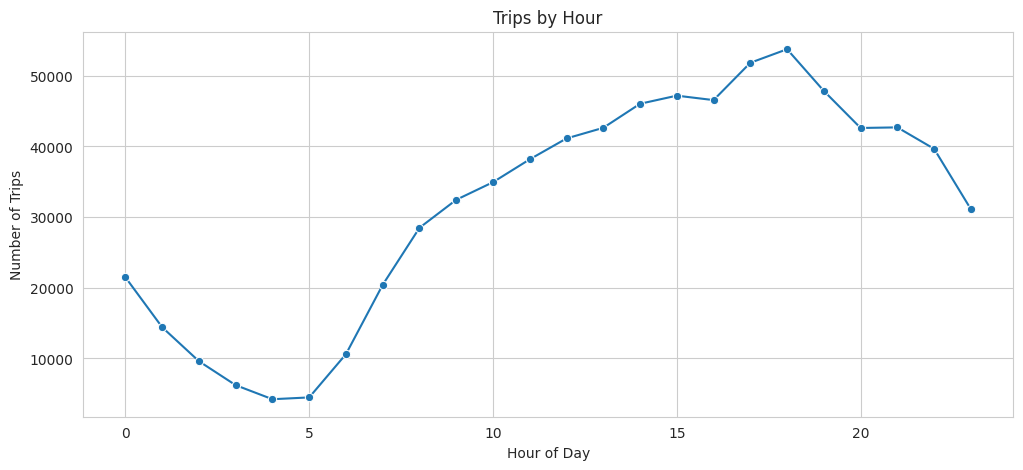

In [140]:
# Task 10: Hourly Trip Analysis
hourly_trips = (
    df.groupby("pickup_hour")
      .size()
      .reset_index(name="trip_count")
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_trips,
    x="pickup_hour",
    y="trip_count",
    marker="o"
)

plt.title("Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.grid(True)

plt.show()

#Trip demand is lowest during the early morning hours (3 AM–5 AM). Demand rises significantly after 6 AM and reaches its peak during the evening rush hours around 5 PM–6 PM.
#This pattern reflects commuter travel behavior in New York City.

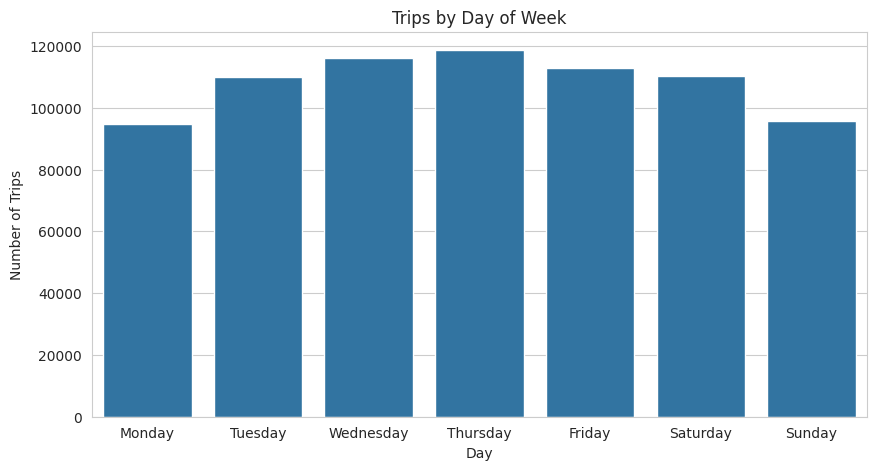

In [141]:
# Task 11: Day of Week Analysis
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_trips = (
    df.groupby("pickup_day")
      .size()
      .reset_index(name="trip_count")
)

daily_trips["pickup_day"] = pd.Categorical(
    daily_trips["pickup_day"],
    categories=day_order,
    ordered=True
)

daily_trips = daily_trips.sort_values("pickup_day")

plt.figure(figsize=(10,5))

sns.barplot(
    data=daily_trips,
    x="pickup_day",
    y="trip_count"
)

plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")

plt.show()

#Thursday records the highest number of taxi trips, while Monday and Sunday have comparatively lower demand.
#Overall, trip activity remains consistently high throughout the week, demonstrating steady transportation needs across weekdays and weekends.

In [142]:
#Business Insight:
#Taxi availability and driver allocation should be increased during evening peak hours and high-demand months such as May and October to maximize revenue opportunities.

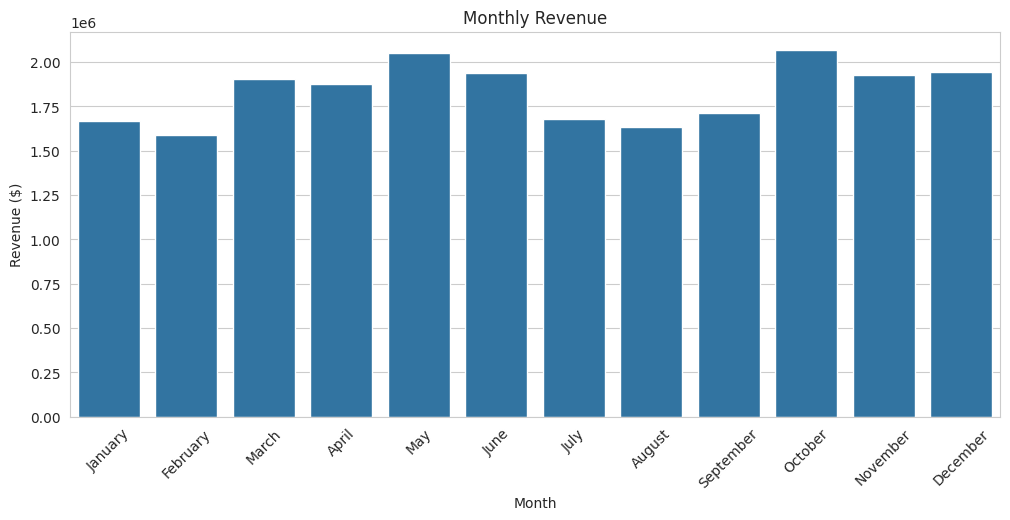

In [143]:
# Task 12: Monthly Revenue Analysis
monthly_revenue = (
    df.groupby("pickup_month")["total_amount"]
      .sum()
      .reset_index()
)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_revenue["pickup_month"] = pd.Categorical(
    monthly_revenue["pickup_month"],
    categories=month_order,
    ordered=True
)

monthly_revenue = monthly_revenue.sort_values("pickup_month")

plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_revenue,
    x="pickup_month",
    y="total_amount"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")

plt.show()

#Monthly revenue remains relatively stable throughout the year.
#October generated the highest revenue, followed closely by May and June.
#February recorded the lowest revenue among all months.

#Business Insight:

#Revenue trends closely follow trip demand patterns.
#Taxi operators should prepare for increased demand during high-revenue months such as October, May, and June by ensuring sufficient driver availability and vehicle capacity.

In [144]:
# Task 13: Highest Revenue Months
monthly_revenue.sort_values(
    "total_amount",
    ascending=False
).head(12)

#October generated the highest revenue, followed by May and June.
#These months represent the strongest earning opportunities for taxi operators throughout the year.

,pickup_month,total_amount
10,October,2069082.52
8,May,2051588.41
2,December,1945062.27
6,June,1940222.23
9,November,1929067.29
7,March,1904031.12
0,April,1876802.81
11,September,1713646.27
5,July,1681830.64
4,January,1667919.22


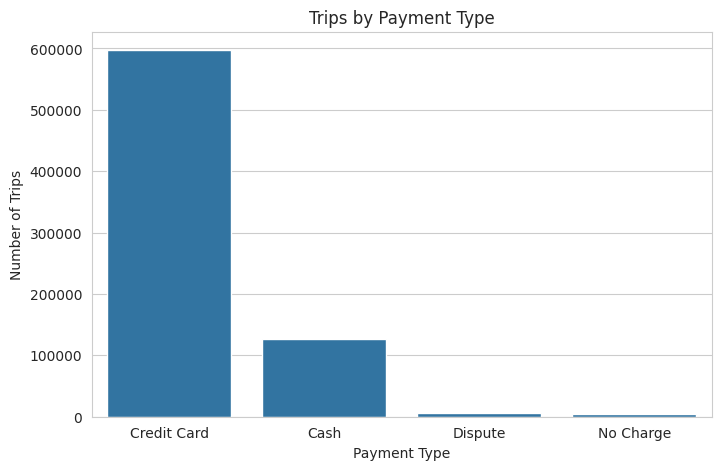

In [145]:
# Task 14: Payment Type Analysis

#Step 1: Convert Payment Codes to Labels

payment_mapping = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute"
}

df["payment_label"] = df["payment_type"].map(payment_mapping)

#Step 2: Count Trips by Payment Type

payment_counts = (
    df["payment_label"]
      .value_counts()
      .reset_index()
)

payment_counts.columns = [
    "payment_type",
    "trip_count"
]

payment_counts

#Step 3: Create Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_counts,
    x="payment_type",
    y="trip_count"
)

plt.title("Trips by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")

plt.show()

#Credit Card is the dominant payment method used by passengers.
#Cash is the second most common payment method.
#Dispute and No Charge transactions account for only a small fraction of total trips.

#Business Insight:

#The overwhelming preference for credit card payments highlights the importance of digital payment systems.
#Taxi operators should prioritize maintaining reliable electronic payment infrastructure while reducing payment disputes.

In [146]:
# Task 15: Average Tip by Payment Type

tip_analysis = (
    df.groupby("payment_label")["tip_amount"]
      .mean()
      .reset_index()
)

tip_analysis

#Credit card trips generate significantly higher recorded tips than all other payment methods.
#Cash transactions show almost no recorded tips because cash tips are often not captured in electronic records.

#Business Insight:
#Drivers earn substantially higher recorded gratuities on credit card transactions. Encouraging electronic payments may improve tip transparency and increase driver earnings.

,payment_label,tip_amount
0,Cash,0.000391
1,Credit Card,4.401841
2,Dispute,0.024940
3,No Charge,0.010933


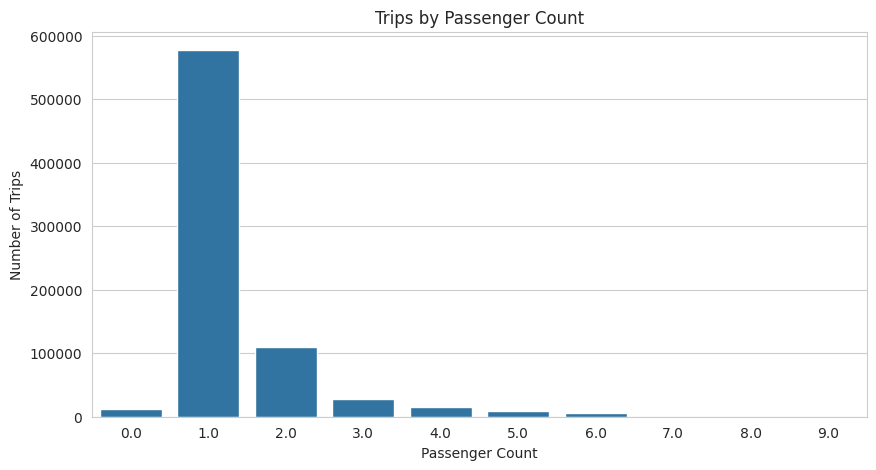

In [147]:
# Task 16: Passenger Count Analysis

#code
passenger_analysis = (
    df.groupby("passenger_count")
      .size()
      .reset_index(name="trip_count")
)

passenger_analysis

#Visualization

plt.figure(figsize=(10,5))

sns.barplot(
    data=passenger_analysis,
    x="passenger_count",
    y="trip_count"
)

plt.title("Trips by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")

plt.show()

#Single-passenger trips dominate the dataset.
#Trip volume decreases significantly as passenger count increases.
#Groups of five or more passengers represent a relatively small portion of total taxi demand.

#Business Insight:
#Most taxi demand comes from solo travelers. Fleet planning and pricing strategies should prioritize serving individual passengers while maintaining adequate capacity for larger groups.

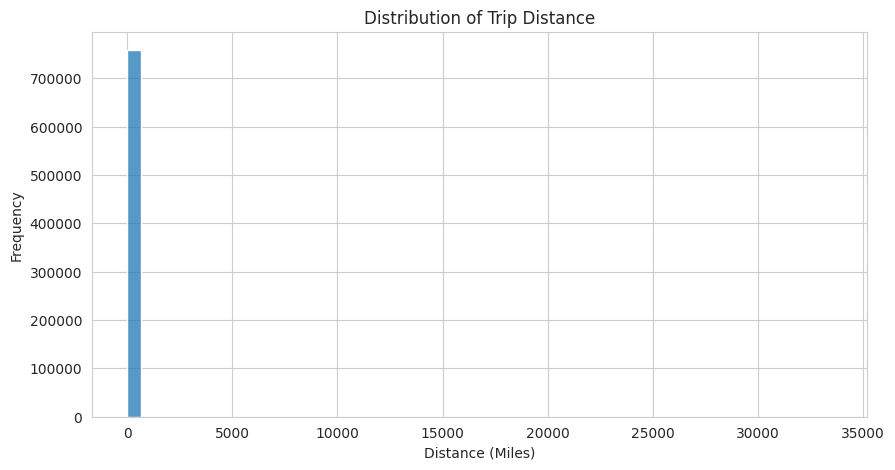

,trip_distance
count,758610.000000
mean,3.725472
std,73.195700
min,0.000000
25%,1.050000
50%,1.800000
75%,3.410000
max,33496.830000


In [148]:
# Task 17: Trip Distance Analysis

plt.figure(figsize=(10,5))

sns.histplot(
    df["trip_distance"],
    bins=50
)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance (Miles)")
plt.ylabel("Frequency")

plt.show()

#Distance Statistics

df["trip_distance"].describe()

In [149]:
# Task 17A: Identify Trip Distance Outliers

df["trip_distance"].describe(percentiles=[0.90,0.95,0.99])

,trip_distance
count,758610.000000
mean,3.725472
std,73.195700
min,0.000000
50%,1.800000
90%,9.180000
95%,15.490000
99%,20.210000
max,33496.830000


In [150]:
# Task 17B: Remove Extreme Distance Outliers
distance_cutoff = df["trip_distance"].quantile(0.99)

print("99th Percentile:", distance_cutoff)

distance_df = df[
    df["trip_distance"] <= distance_cutoff
]

#Check the new size:
print(distance_df.shape)

99th Percentile: 20.21
(751027, 27)


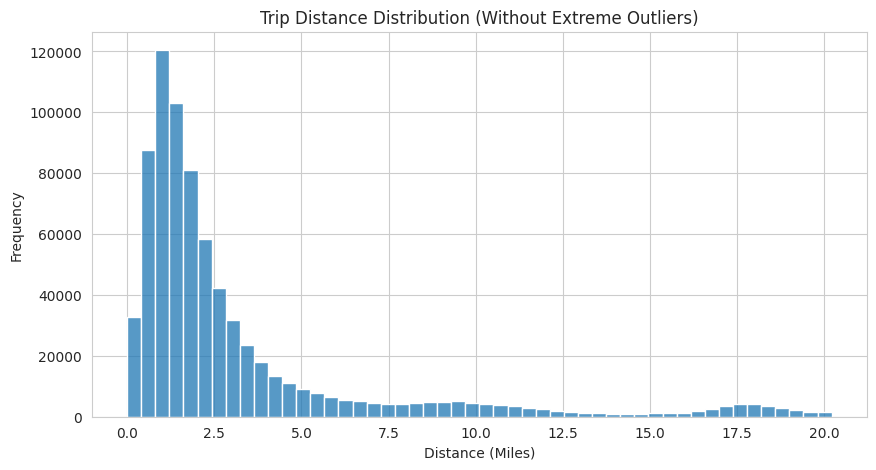

In [151]:
# Task 17C: Trip Distance Distribution After Outlier Removal

plt.figure(figsize=(10,5))

sns.histplot(
    distance_df["trip_distance"],
    bins=50
)

plt.title("Trip Distance Distribution (Without Extreme Outliers)")
plt.xlabel("Distance (Miles)")
plt.ylabel("Frequency")

plt.show()

# Interpretation:
# Most NYC taxi trips are short-distance journeys.
# The highest concentration of trips falls between 1 and 3 miles.
# Trip frequency decreases steadily as distance increases, indicating a right-skewed distribution.

# Business Insight:
# NYC taxi demand is primarily driven by short urban trips.
# Fleet availability should be concentrated in high-density city areas where short trips occur frequently.
# Long-distance trips are relatively rare and contribute a smaller share of total ride volume.

In [152]:
# Task 18: Top 10 Pickup Zones

pickup_zones = (
    df.groupby("PULocationID")
      .size()
      .reset_index(name="trip_count")
      .sort_values("trip_count", ascending=False)
)

pickup_zones.head(10)

# Interpretation:
# The listed pickup zones generate the highest taxi demand in NYC.
# These areas represent major business, tourism, transportation, or residential hubs.

# Business Insight:
# Drivers should prioritize positioning themselves near high-demand pickup zones to maximize ride opportunities and reduce idle time.

,PULocationID,trip_count
122,132,39192
223,237,35831
150,161,35033
222,236,31903
151,162,26953
128,138,25811
175,186,25729
216,230,25386
132,142,24660
159,170,22614


In [153]:
# Task 19: Top 10 Dropoff Zones

dropoff_zones = (
    df.groupby("DOLocationID")
      .size()
      .reset_index(name="trip_count")
      .sort_values("trip_count", ascending=False)
)

dropoff_zones.head(10)

# Interpretation:
# These locations receive the highest number of taxi dropoffs in NYC.
# High dropoff activity indicates popular destinations such as business districts,
# airports, residential areas, and tourist attractions.

# Business Insight:
# Drivers can target these zones after passenger dropoff because
# they are likely to generate return-trip demand and reduce empty travel time.

,DOLocationID,trip_count
230,236,33095
231,237,31858
156,161,29141
224,230,23166
165,170,22322
157,162,21554
137,142,21110
233,239,20768
136,141,20075
67,68,19220


In [154]:
# Task 20: Load Taxi Zone Shapefile

import geopandas as gpd

zones = gpd.read_file(
    "taxi_zones/taxi_zones.shp"
)

zones.head()

zones.columns

Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')

In [155]:
# Task 21: Top Pickup Zones with Zone Names

top_pickups = pickup_zones.head(10)

top_pickups = top_pickups.merge(
    zones[["LocationID", "zone", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

top_pickups[
    ["zone", "borough", "trip_count"]
]

,zone,borough,trip_count
0,JFK Airport,Queens,39192
1,Upper East Side South,Manhattan,35831
2,Midtown Center,Manhattan,35033
3,Upper East Side North,Manhattan,31903
4,Midtown East,Manhattan,26953
5,LaGuardia Airport,Queens,25811
6,Penn Station/Madison Sq West,Manhattan,25729
7,Times Sq/Theatre District,Manhattan,25386
8,Lincoln Square East,Manhattan,24660
9,Murray Hill,Manhattan,22614


In [156]:
# Task 22: Top Dropoff Zones with Zone Names

top_dropoffs = dropoff_zones.head(10)

top_dropoffs = top_dropoffs.merge(
    zones[["LocationID", "zone", "borough"]],
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

top_dropoffs[
    ["zone", "borough", "trip_count"]
]

# Interpretation:
# Manhattan dominates both pickup and dropoff activity.
# Major transportation hubs such as JFK Airport, LaGuardia Airport,
# Penn Station, and Times Square generate significant taxi demand.
# Business and tourist districts are the primary drivers of NYC taxi traffic.

# Business Insight:
# Fleet allocation should prioritize Manhattan business districts
# and airport corridors where ride demand remains consistently high.
# Dynamic driver positioning near airports and Midtown can improve utilization and revenue.

,zone,borough,trip_count
0,Upper East Side North,Manhattan,33095
1,Upper East Side South,Manhattan,31858
2,Midtown Center,Manhattan,29141
3,Times Sq/Theatre District,Manhattan,23166
4,Murray Hill,Manhattan,22322
5,Midtown East,Manhattan,21554
6,Lincoln Square East,Manhattan,21110
7,Upper West Side South,Manhattan,20768
8,Lenox Hill West,Manhattan,20075
9,East Chelsea,Manhattan,19220


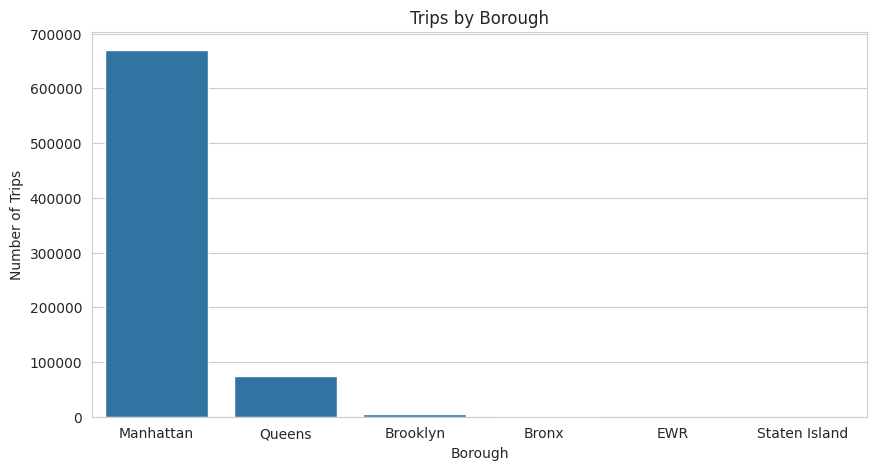

In [157]:
# Task 23: Borough-Level Pickup Demand

borough_demand = df.merge(
    zones[["LocationID", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

borough_summary = (
    borough_demand.groupby("borough")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

borough_summary

#create Chart

plt.figure(figsize=(10,5))

sns.barplot(
    data=borough_summary,
    x="borough",
    y="trip_count"
)

plt.title("Trips by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Trips")

plt.show()

# Interpretation:
# Manhattan generates the majority of NYC taxi trips,
# followed by Queens. The remaining boroughs contribute
# a much smaller portion of overall taxi demand.

# Business Insight:
# Taxi operators should concentrate fleet availability
# in Manhattan and Queens where passenger demand is highest.
# Airport-related traffic significantly boosts Queens demand.

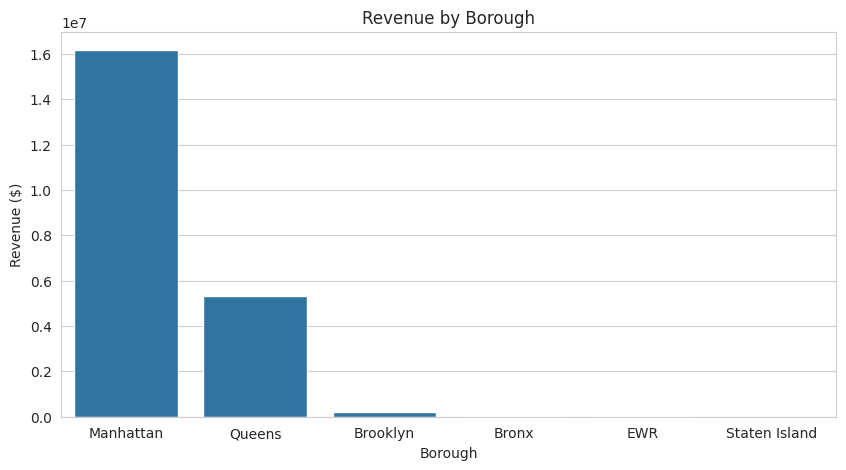

In [158]:
# Task 24: Revenue by Borough

borough_revenue = (
    borough_demand.groupby("borough")["total_amount"]
    .sum()
    .reset_index()
    .sort_values("total_amount", ascending=False)
)

borough_revenue

#create Chart

plt.figure(figsize=(10,5))

sns.barplot(
    data=borough_revenue,
    x="borough",
    y="total_amount"
)

plt.title("Revenue by Borough")
plt.xlabel("Borough")
plt.ylabel("Revenue ($)")

plt.show()

# Interpretation:
# Manhattan generates the largest share of taxi revenue,
# followed by Queens. Revenue patterns closely match trip demand.

# Business Insight:
# Revenue optimization efforts should focus on Manhattan
# and airport-connected zones in Queens where both trip
# volume and fare generation are highest.

In [159]:
# Task 25: Executive Summary

# Executive Summary

# 1. Taxi demand remains relatively stable throughout the year,
#    with peak activity observed in May and October.

# 2. Evening hours (approximately 5 PM to 7 PM) generate the
#    highest number of taxi trips, indicating strong commuter demand.

# 3. Manhattan dominates both trip volume and revenue generation,
#    while Queens ranks second due to airport traffic.

# 4. Major demand hotspots include:
#    - JFK Airport
#    - LaGuardia Airport
#    - Midtown Center
#    - Times Square
#    - Upper East Side

# 5. Most trips are short-distance rides between 1 and 3 miles,
#    highlighting the importance of urban transportation services.

# 6. Credit Card is the dominant payment method and generates
#    virtually all tip revenue.

# 7. Strategic fleet deployment in Manhattan business districts,
#    tourist zones, and airport corridors can maximize utilization
#    and revenue opportunities.

In [160]:
# Task 26: Final Business Recommendations

# Recommendation 1:
# Increase driver availability during evening peak hours
# (5 PM - 7 PM) to meet high passenger demand.

# Recommendation 2:
# Prioritize fleet deployment around Midtown Manhattan,
# Times Square, JFK Airport, and LaGuardia Airport.

# Recommendation 3:
# Encourage digital payments since credit card transactions
# generate significantly higher tip revenue.

# Recommendation 4:
# Use demand forecasting models to dynamically allocate
# drivers based on time, location, and seasonal demand.

# Recommendation 5:
# Focus marketing and service expansion efforts in
# Manhattan and Queens where revenue potential is highest.


In [161]:
# final Save

# Final Save

df.to_parquet(
    "output/final_nyc_taxi_analysis.parquet",
    index=False
)

print("Project Completed Successfully")

Project Completed Successfully


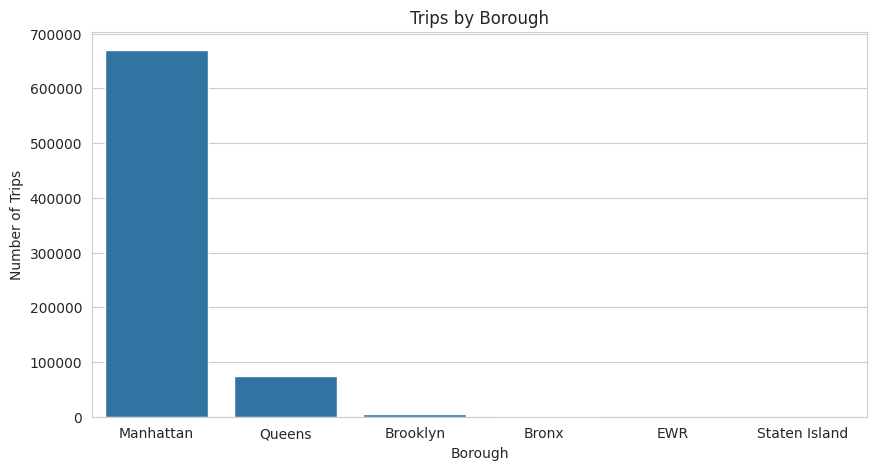

In [162]:
# Task 23: Borough-Level Pickup Demand

borough_demand = df.merge(
    zones[["LocationID", "borough"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

borough_summary = (
    borough_demand.groupby("borough")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

borough_summary

plt.figure(figsize=(10,5))

sns.barplot(
    data=borough_summary,
    x="borough",
    y="trip_count"
)

plt.title("Trips by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Trips")
plt.show()

# Manhattan generates the highest taxi pickup demand, followed by Queens.
# Taxi activity is concentrated in commercial, tourist, and airport-connected boroughs.



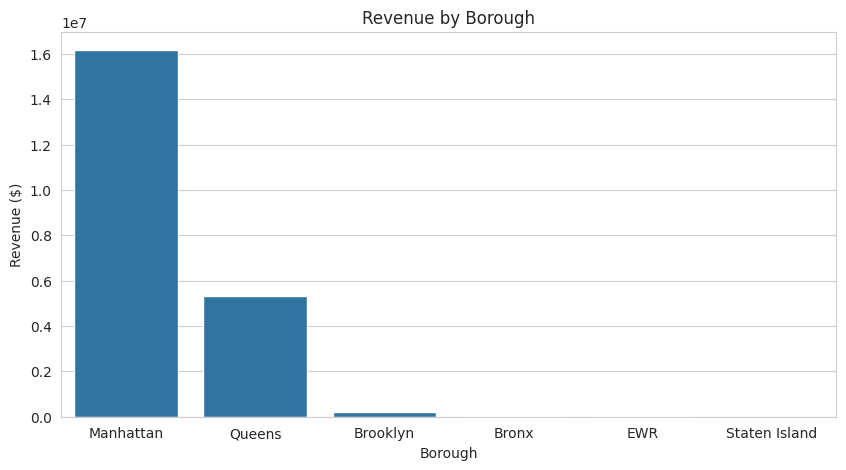

In [163]:
# Task 24: Revenue by Borough

borough_revenue = (
    borough_demand.groupby("borough")["total_amount"]
    .sum()
    .reset_index()
    .sort_values("total_amount", ascending=False)
)

borough_revenue

plt.figure(figsize=(10,5))

sns.barplot(
    data=borough_revenue,
    x="borough",
    y="total_amount"
)

plt.title("Revenue by Borough")
plt.xlabel("Borough")
plt.ylabel("Revenue ($)")
plt.show()

# Manhattan contributes the largest share of taxi revenue.
# Queens is the second-highest contributor due to airport traffic from JFK and LaGuardia.

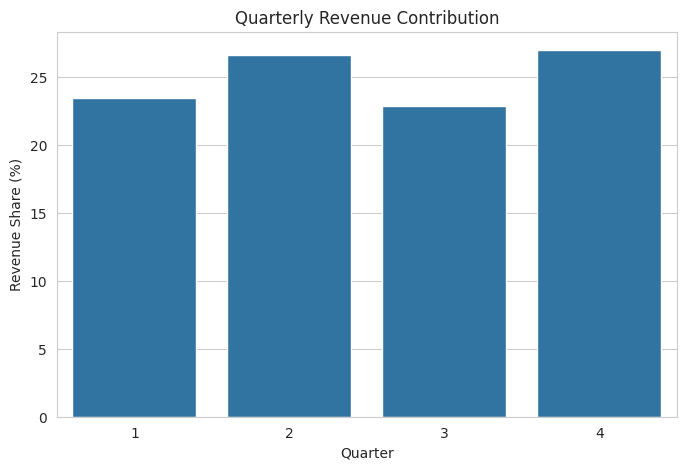

In [164]:
# Task 25: Quarterly Revenue Contribution

df["quarter"] = df["tpep_pickup_datetime"].dt.quarter

quarterly_revenue = (
    df.groupby("quarter")["total_amount"]
    .sum()
    .reset_index()
)

quarterly_revenue["revenue_share_percent"] = (
    quarterly_revenue["total_amount"] / quarterly_revenue["total_amount"].sum()
) * 100

quarterly_revenue

plt.figure(figsize=(8,5))

sns.barplot(
    data=quarterly_revenue,
    x="quarter",
    y="revenue_share_percent"
)

plt.title("Quarterly Revenue Contribution")
plt.xlabel("Quarter")
plt.ylabel("Revenue Share (%)")
plt.show()

# Revenue is distributed across all four quarters, with stronger contribution from high-demand months.
# Quarterly revenue helps identify seasonal business performance.

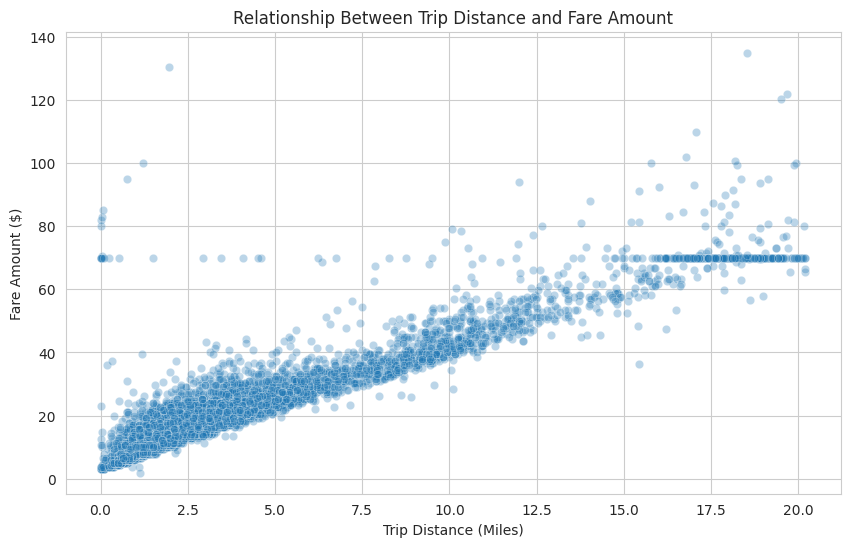

In [165]:
# Task 26: Distance vs Fare Relationship

fare_distance_df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["trip_distance"] <= df["trip_distance"].quantile(0.99))
]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=fare_distance_df.sample(10000, random_state=42),
    x="trip_distance",
    y="fare_amount",
    alpha=0.3
)

plt.title("Relationship Between Trip Distance and Fare Amount")
plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Fare Amount ($)")
plt.show()

# Fare amount generally increases as trip distance increases.
# Some variation exists because fare also depends on time, traffic, surcharges, and rate code.

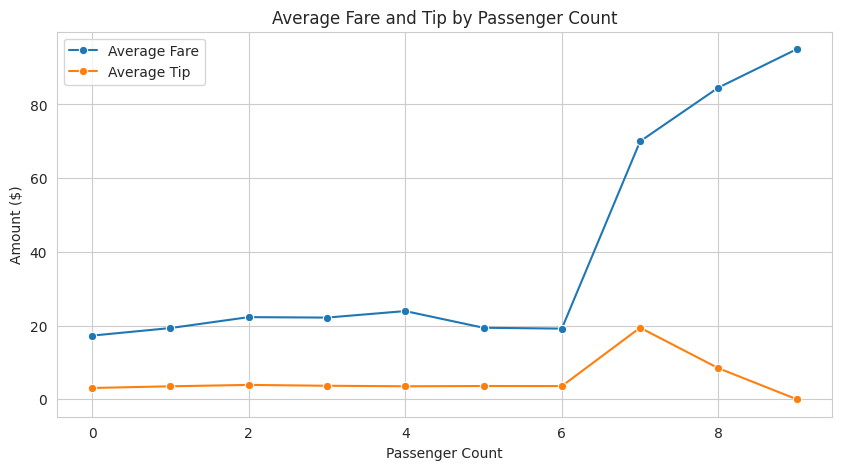

In [166]:
# Task 27: Fare and Tips by Passenger Count

fare_tip_passenger = (
    df.groupby("passenger_count")[["fare_amount", "tip_amount", "total_amount"]]
    .mean()
    .reset_index()
)

fare_tip_passenger

plt.figure(figsize=(10,5))

sns.lineplot(
    data=fare_tip_passenger,
    x="passenger_count",
    y="fare_amount",
    marker="o",
    label="Average Fare"
)

sns.lineplot(
    data=fare_tip_passenger,
    x="passenger_count",
    y="tip_amount",
    marker="o",
    label="Average Tip"
)

plt.title("Average Fare and Tip by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Amount ($)")
plt.legend()
plt.show()

# Single-passenger trips dominate the dataset.
# Fare and tip amounts do not increase proportionally with passenger count.

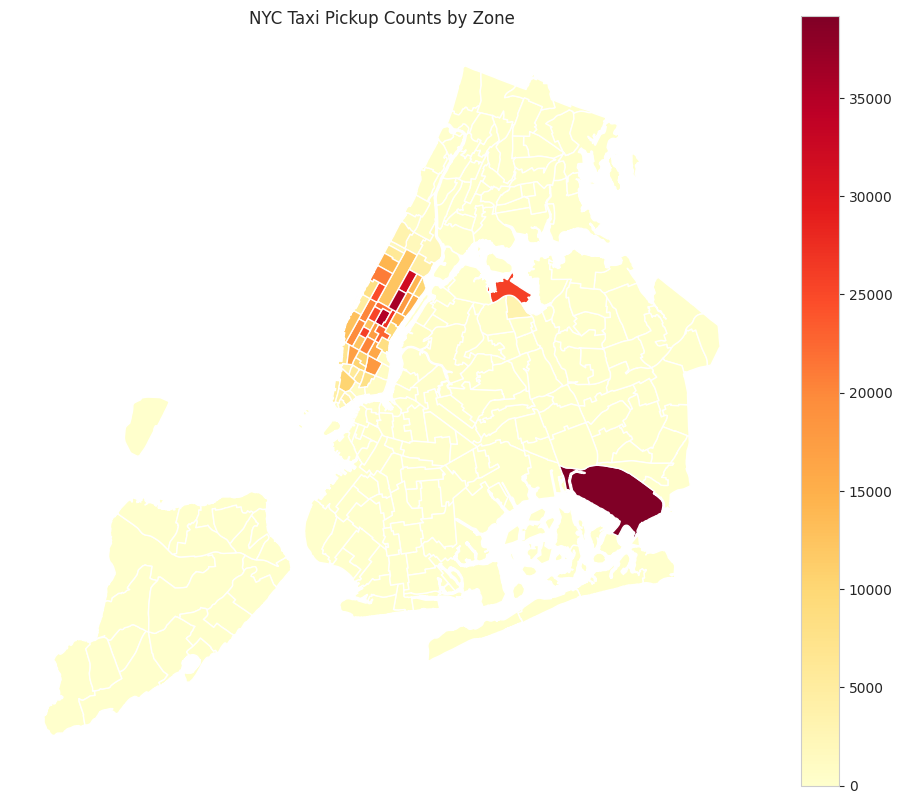

In [167]:
# Task 28: Taxi Zone Pickup Map

zone_trip_counts = (
    df.groupby("PULocationID")
    .size()
    .reset_index(name="pickup_count")
)

zones_with_trips = zones.merge(
    zone_trip_counts,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

zones_with_trips["pickup_count"] = zones_with_trips["pickup_count"].fillna(0)

fig, ax = plt.subplots(figsize=(12,10))

zones_with_trips.plot(
    column="pickup_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax
)

ax.set_title("NYC Taxi Pickup Counts by Zone")
ax.axis("off")

plt.show()

# Pickup density is highest in Manhattan and airport-connected zones.
# The map confirms that demand is geographically concentrated.

In [168]:
# Task 29: Slow Routes by Average Speed

route_speed = df[
    (df["trip_distance"] > 0) &
    (df["trip_duration"] > 0)
].copy()

route_speed["speed_mph"] = (
    route_speed["trip_distance"] / (route_speed["trip_duration"] / 60)
)

slow_routes = (
    route_speed.groupby(["PULocationID", "DOLocationID", "pickup_hour"])
    .agg(
        avg_distance=("trip_distance", "mean"),
        avg_duration=("trip_duration", "mean"),
        avg_speed=("speed_mph", "mean"),
        trip_count=("VendorID", "count")
    )
    .reset_index()
)

slow_routes = slow_routes[slow_routes["trip_count"] >= 20]

slow_routes.sort_values("avg_speed").head(10)

# Slow routes indicate possible congestion or operational bottlenecks.
# These routes can be studied for dispatch and routing optimization.

,PULocationID,DOLocationID,pickup_hour,avg_distance,avg_duration,avg_speed,trip_count
64988,186,100,13,0.616829,14.003252,3.403389,41
77684,233,230,13,1.062609,18.243478,3.863220,23
64580,186,48,10,0.988261,16.838406,3.922485,23
64987,186,100,12,0.588108,13.136486,3.975848,37
64583,186,48,13,0.984310,16.533621,3.979116,58
57002,162,230,13,0.805185,13.653395,4.011018,54
65927,186,230,13,1.017822,18.459406,4.014293,101
64991,186,100,16,0.556923,10.606410,4.031838,26
12132,68,100,11,0.830952,15.018254,4.058940,21
55115,161,230,17,0.763571,12.635714,4.059677,98


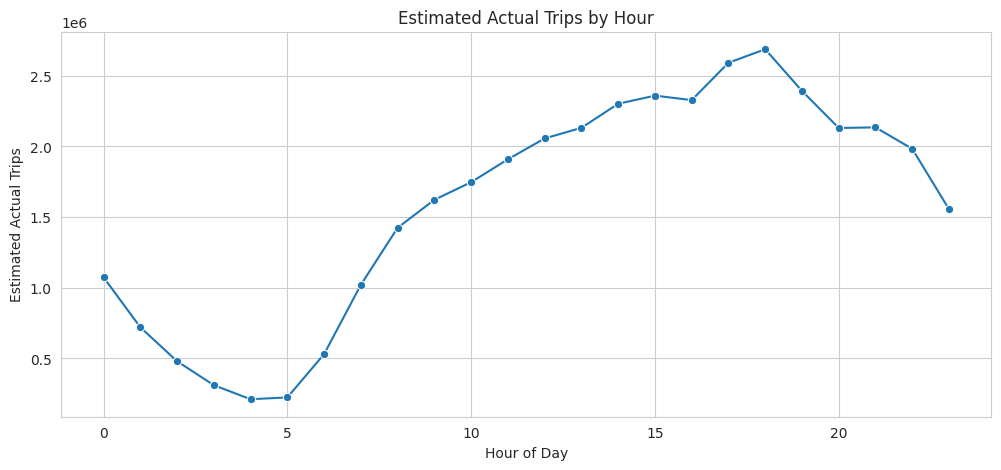

In [169]:
# Task 30: Busy Hours and Scaled Trip Count

hourly_trip_count = (
    df.groupby("pickup_hour")
    .size()
    .reset_index(name="sample_trip_count")
)

sample_fraction = 0.02

hourly_trip_count["estimated_actual_trips"] = (
    hourly_trip_count["sample_trip_count"] / sample_fraction
)

hourly_trip_count.sort_values(
    "estimated_actual_trips",
    ascending=False
).head(5)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=hourly_trip_count,
    x="pickup_hour",
    y="estimated_actual_trips",
    marker="o"
)

plt.title("Estimated Actual Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Estimated Actual Trips")
plt.grid(True)
plt.show()

# Evening hours show the highest estimated actual trip volume.
# Driver availability should be increased during these hours.

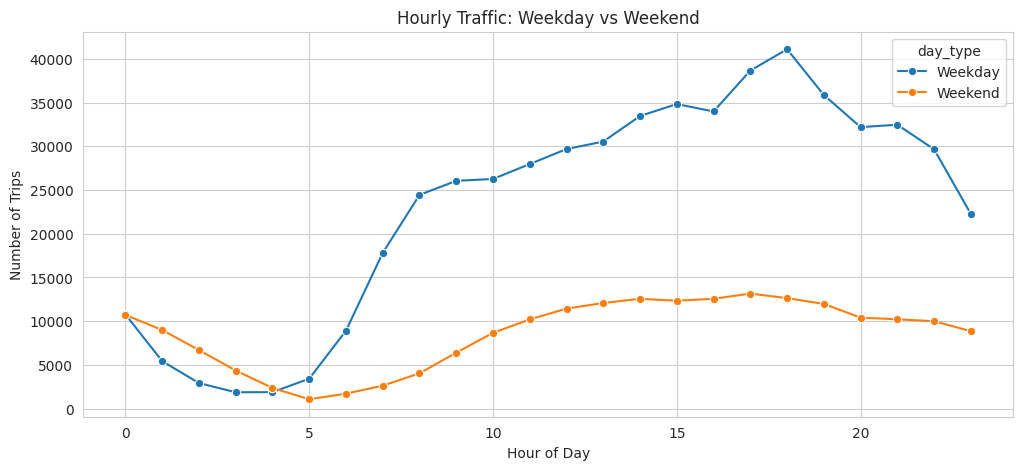

In [170]:
# Task 31: Weekday vs Weekend Hourly Traffic

weekday_weekend = (
    df.groupby(["pickup_hour", "is_weekend"])
    .size()
    .reset_index(name="trip_count")
)

weekday_weekend["day_type"] = weekday_weekend["is_weekend"].map(
    {False: "Weekday", True: "Weekend"}
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=weekday_weekend,
    x="pickup_hour",
    y="trip_count",
    hue="day_type",
    marker="o"
)

plt.title("Hourly Traffic: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

# Weekday demand is stronger during commuter hours.
# Weekend demand is more spread out and may remain stronger during late evening hours.

In [171]:
# Task 32: Pickup to Dropoff Ratio by Zone

pickup_counts = df.groupby("PULocationID").size().reset_index(name="pickup_count")
dropoff_counts = df.groupby("DOLocationID").size().reset_index(name="dropoff_count")

zone_ratio = pickup_counts.merge(
    dropoff_counts,
    left_on="PULocationID",
    right_on="DOLocationID",
    how="outer"
)

zone_ratio["LocationID"] = zone_ratio["PULocationID"].fillna(zone_ratio["DOLocationID"])

zone_ratio["pickup_count"] = zone_ratio["pickup_count"].fillna(0)
zone_ratio["dropoff_count"] = zone_ratio["dropoff_count"].fillna(0)

zone_ratio["pickup_dropoff_ratio"] = (
    zone_ratio["pickup_count"] / zone_ratio["dropoff_count"].replace(0, np.nan)
)

zone_ratio = zone_ratio.merge(
    zones[["LocationID", "zone", "borough"]],
    on="LocationID",
    how="left"
)

zone_ratio.sort_values("pickup_dropoff_ratio", ascending=False).head(10)




# Zones with high pickup/dropoff ratios are strong trip-origin areas.
# Zones with low ratios are mainly destination-heavy zones.

,PULocationID,pickup_count,DOLocationID,dropoff_count,LocationID,pickup_dropoff_ratio,zone,borough
69,70.0,3357.0,70,450,70.0,7.460000,East Elmhurst,Queens
127,132.0,39192.0,132,9231,132.0,4.245694,JFK Airport,Queens
133,138.0,25811.0,138,9828,138.0,2.626272,LaGuardia Airport,Queens
43,44.0,5.0,44,2,44.0,2.500000,Charleston/Tottenville,Staten Island
4,5.0,10.0,5,6,5.0,1.666667,Arden Heights,Staten Island
181,186.0,25729.0,186,16470,186.0,1.562174,Penn Station/Madison Sq West,Manhattan
109,114.0,10326.0,114,7165,114.0,1.441172,Greenwich Village South,Manhattan
243,249.0,17041.0,249,12326,249.0,1.382525,West Village,Manhattan
42,43.0,12304.0,43,9321,43.0,1.320030,Central Park,Manhattan
157,162.0,26953.0,162,21554,162.0,1.250487,Midtown East,Manhattan


In [172]:
zone_ratio.sort_values("pickup_dropoff_ratio", ascending=True).head(10)

,PULocationID,pickup_count,DOLocationID,dropoff_count,LocationID,pickup_dropoff_ratio,zone,borough
26,NaN,0.0,27,18,27.0,0.0,Breezy Point/Fort Tilden/Riis Beach,Queens
239,NaN,0.0,245,16,245.0,0.0,West Brighton,Staten Island
57,NaN,0.0,58,14,58.0,0.0,Country Club,Bronx
105,NaN,0.0,109,6,109.0,0.0,Great Kills,Staten Island
200,NaN,0.0,206,21,206.0,0.0,Saint George/New Brighton,Staten Island
98,NaN,0.0,99,1,99.0,0.0,Freshkills Park,Staten Island
113,NaN,0.0,118,19,118.0,0.0,Heartland Village/Todt Hill,Staten Island
182,NaN,0.0,187,6,187.0,0.0,Port Richmond,Staten Island
247,NaN,0.0,253,11,253.0,0.0,Willets Point,Queens
245,NaN,0.0,251,20,251.0,0.0,Westerleigh,Staten Island


In [173]:
# Task 33: Night-Time High-Traffic Zones

night_df = df[
    (df["pickup_hour"] >= 23) |
    (df["pickup_hour"] <= 5)
]

night_pickups = (
    night_df.groupby("PULocationID")
    .size()
    .reset_index(name="night_pickup_count")
    .merge(
        zones[["LocationID", "zone", "borough"]],
        left_on="PULocationID",
        right_on="LocationID",
        how="left"
    )
    .sort_values("night_pickup_count", ascending=False)
)

night_pickups.head(10)

,PULocationID,night_pickup_count,LocationID,zone,borough
61,79,6566,79.0,East Village,Manhattan
98,132,6055,132.0,JFK Airport,Queens
202,249,5382,249.0,West Village,Manhattan
34,48,4147,48.0,Clinton East,Manhattan
114,148,4073,148.0,Lower East Side,Manhattan
83,114,3677,114.0,Greenwich Village South,Manhattan
185,230,3413,230.0,Times Sq/Theatre District,Manhattan
147,186,2887,186.0,Penn Station/Madison Sq West,Manhattan
129,164,2581,164.0,Midtown South,Manhattan
50,68,2507,68.0,East Chelsea,Manhattan


In [174]:
# Task 33: Night-Time High-Traffic Zones

night_df = df[
    (df["pickup_hour"] >= 23) |
    (df["pickup_hour"] <= 5)
]

night_pickups = (
    night_df.groupby("PULocationID")
    .size()
    .reset_index(name="night_pickup_count")
    .merge(
        zones[["LocationID", "zone", "borough"]],
        left_on="PULocationID",
        right_on="LocationID",
        how="left"
    )
    .sort_values("night_pickup_count", ascending=False)
)

night_pickups.head(10)

# Night traffic is concentrated in nightlife, airport, and central Manhattan zones.
# Late-night fleet planning should focus on these zones.

,PULocationID,night_pickup_count,LocationID,zone,borough
61,79,6566,79.0,East Village,Manhattan
98,132,6055,132.0,JFK Airport,Queens
202,249,5382,249.0,West Village,Manhattan
34,48,4147,48.0,Clinton East,Manhattan
114,148,4073,148.0,Lower East Side,Manhattan
83,114,3677,114.0,Greenwich Village South,Manhattan
185,230,3413,230.0,Times Sq/Theatre District,Manhattan
147,186,2887,186.0,Penn Station/Madison Sq West,Manhattan
129,164,2581,164.0,Midtown South,Manhattan
50,68,2507,68.0,East Chelsea,Manhattan


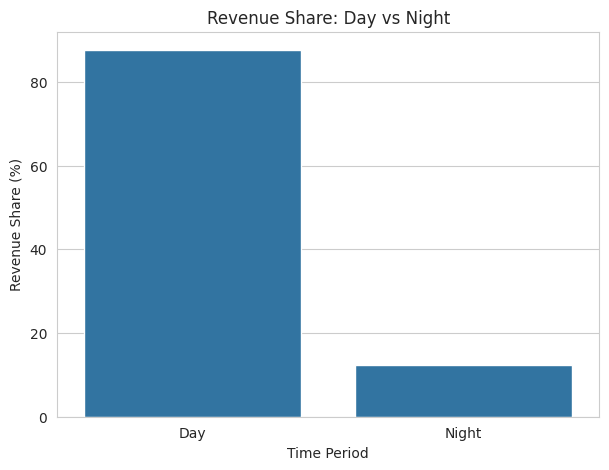

In [175]:
# Task 34: Day vs Night Revenue Share

df["time_period"] = np.where(
    (df["pickup_hour"] >= 23) | (df["pickup_hour"] <= 5),
    "Night",
    "Day"
)

revenue_period = (
    df.groupby("time_period")["total_amount"]
    .sum()
    .reset_index()
)

revenue_period["revenue_share_percent"] = (
    revenue_period["total_amount"] / revenue_period["total_amount"].sum()
) * 100

revenue_period

plt.figure(figsize=(7,5))

sns.barplot(
    data=revenue_period,
    x="time_period",
    y="revenue_share_percent"
)

plt.title("Revenue Share: Day vs Night")
plt.xlabel("Time Period")
plt.ylabel("Revenue Share (%)")
plt.show()

# Daytime trips contribute most of the total revenue.
# Nighttime still represents an important segment for airport and entertainment-related travel.

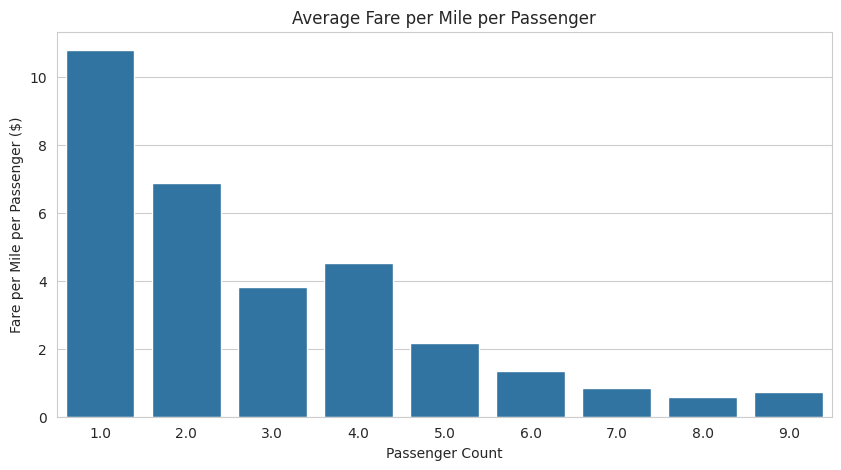

In [176]:
# Task 35: Average Fare per Mile per Passenger

fare_mile_passenger = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["passenger_count"] > 0)
].copy()

fare_mile_passenger["fare_per_mile_per_passenger"] = (
    fare_mile_passenger["fare_amount"] /
    fare_mile_passenger["trip_distance"] /
    fare_mile_passenger["passenger_count"]
)

fare_mile_summary = (
    fare_mile_passenger.groupby("passenger_count")["fare_per_mile_per_passenger"]
    .mean()
    .reset_index()
)

fare_mile_summary

plt.figure(figsize=(10,5))

sns.barplot(
    data=fare_mile_summary,
    x="passenger_count",
    y="fare_per_mile_per_passenger"
)

plt.title("Average Fare per Mile per Passenger")
plt.xlabel("Passenger Count")
plt.ylabel("Fare per Mile per Passenger ($)")
plt.show()

# Fare per mile per passenger decreases as more passengers share the same trip.
# Group rides can be more economical from the passenger perspective.

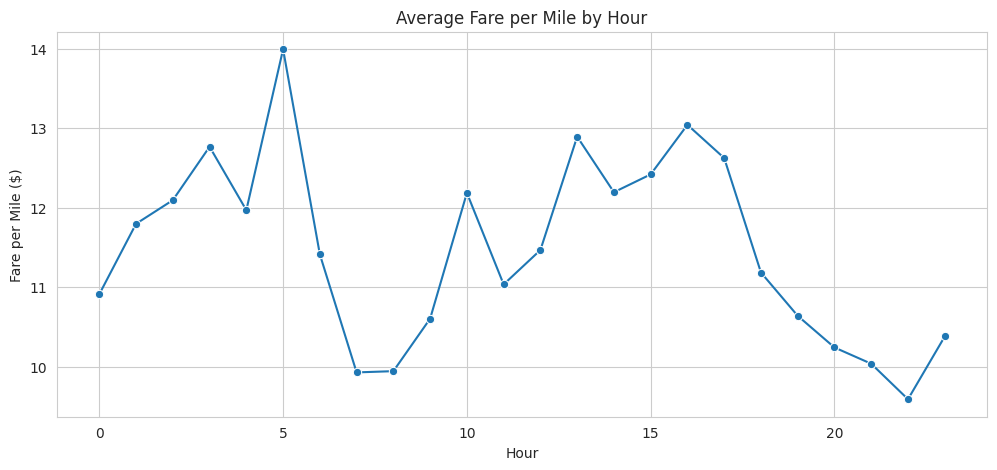

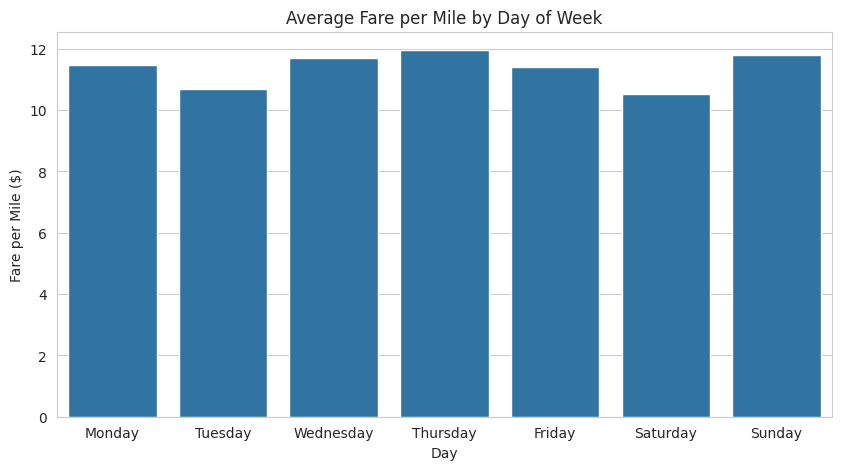

In [177]:
# Task 36: Average Fare per Mile by Hour

fare_hour = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0)
].copy()

fare_hour["fare_per_mile"] = (
    fare_hour["fare_amount"] / fare_hour["trip_distance"]
)

fare_by_hour = (
    fare_hour.groupby("pickup_hour")["fare_per_mile"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=fare_by_hour,
    x="pickup_hour",
    y="fare_per_mile",
    marker="o"
)

plt.title("Average Fare per Mile by Hour")
plt.xlabel("Hour")
plt.ylabel("Fare per Mile ($)")
plt.grid(True)
plt.show()

# Average Fare per Mile by Day

fare_by_day = (
    fare_hour.groupby("pickup_day")["fare_per_mile"]
    .mean()
    .reset_index()
)

fare_by_day["pickup_day"] = pd.Categorical(
    fare_by_day["pickup_day"],
    categories=day_order,
    ordered=True
)

fare_by_day = fare_by_day.sort_values("pickup_day")

plt.figure(figsize=(10,5))

sns.barplot(
    data=fare_by_day,
    x="pickup_day",
    y="fare_per_mile"
)

plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day")
plt.ylabel("Fare per Mile ($)")
plt.show()

# Fare per mile varies by time and day.
# This can reflect congestion, trip mix, surcharges, and route differences.

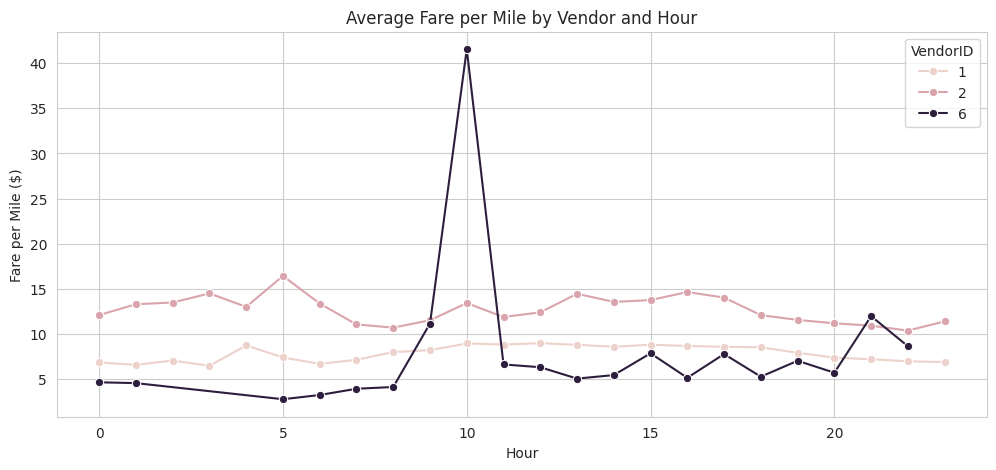

In [178]:
# Task 37: Vendor Fare Comparison

vendor_fare = (
    fare_hour.groupby(["VendorID", "pickup_hour"])["fare_per_mile"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    data=vendor_fare,
    x="pickup_hour",
    y="fare_per_mile",
    hue="VendorID",
    marker="o"
)

plt.title("Average Fare per Mile by Vendor and Hour")
plt.xlabel("Hour")
plt.ylabel("Fare per Mile ($)")
plt.show()

# Vendor-level fare per mile patterns are broadly similar across the day.
# Any differences may reflect trip mix, airport trips, or operating zones.

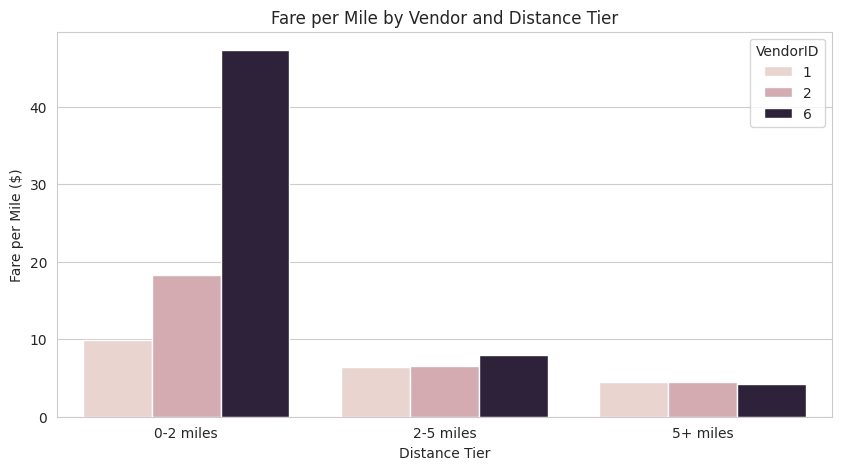

In [179]:
# Task 38: Distance-Tiered Vendor Fare Comparison

fare_hour["distance_tier"] = pd.cut(
    fare_hour["trip_distance"],
    bins=[0, 2, 5, np.inf],
    labels=["0-2 miles", "2-5 miles", "5+ miles"]
)

vendor_tier_fare = (
    fare_hour.groupby(["VendorID", "distance_tier"])["fare_per_mile"]
    .mean()
    .reset_index()
)

vendor_tier_fare

plt.figure(figsize=(10,5))

sns.barplot(
    data=vendor_tier_fare,
    x="distance_tier",
    y="fare_per_mile",
    hue="VendorID"
)

plt.title("Fare per Mile by Vendor and Distance Tier")
plt.xlabel("Distance Tier")
plt.ylabel("Fare per Mile ($)")
plt.show()

# Short-distance trips usually have higher fare per mile.
# Longer trips show lower fare per mile due to fixed charges being spread across more miles.

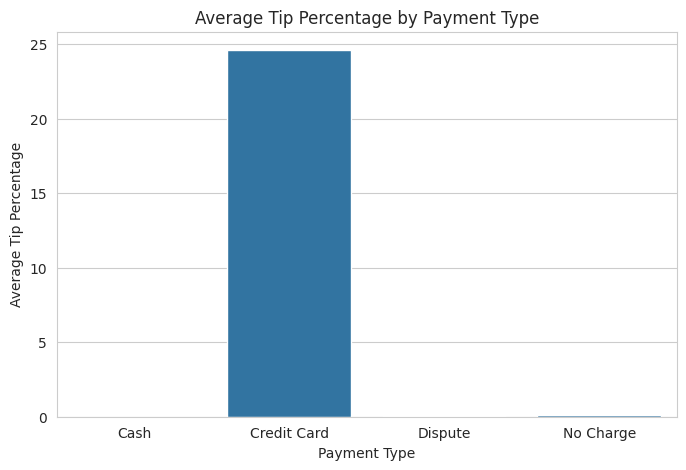

In [180]:
# Task 39: Tip Percentage Analysis

tip_df = df[
    (df["fare_amount"] > 0) &
    (df["tip_amount"] >= 0)
].copy()

tip_df["tip_percent"] = (
    tip_df["tip_amount"] / tip_df["fare_amount"]
) * 100

tip_df = tip_df[tip_df["tip_percent"] <= 100]

tip_summary = (
    tip_df.groupby("payment_label")["tip_percent"]
    .mean()
    .reset_index()
)

tip_summary

plt.figure(figsize=(8,5))

sns.barplot(
    data=tip_summary,
    x="payment_label",
    y="tip_percent"
)

plt.title("Average Tip Percentage by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Average Tip Percentage")
plt.show()

# Credit card payments show the highest recorded tip percentage.
# Cash tips are not reliably captured in the dataset.

# Interpretation:
# Credit Card transactions show an average tip percentage of approximately 25%.
# Cash trips display near-zero recorded tips because cash tips are generally not captured in NYC taxi datasets.
# Dispute and No Charge trips have negligible tip percentages.

# Business Insight:
# Digital payment methods generate the majority of recorded gratuity revenue.
# Taxi operators should continue supporting electronic payment options to maximize tip-related earnings.

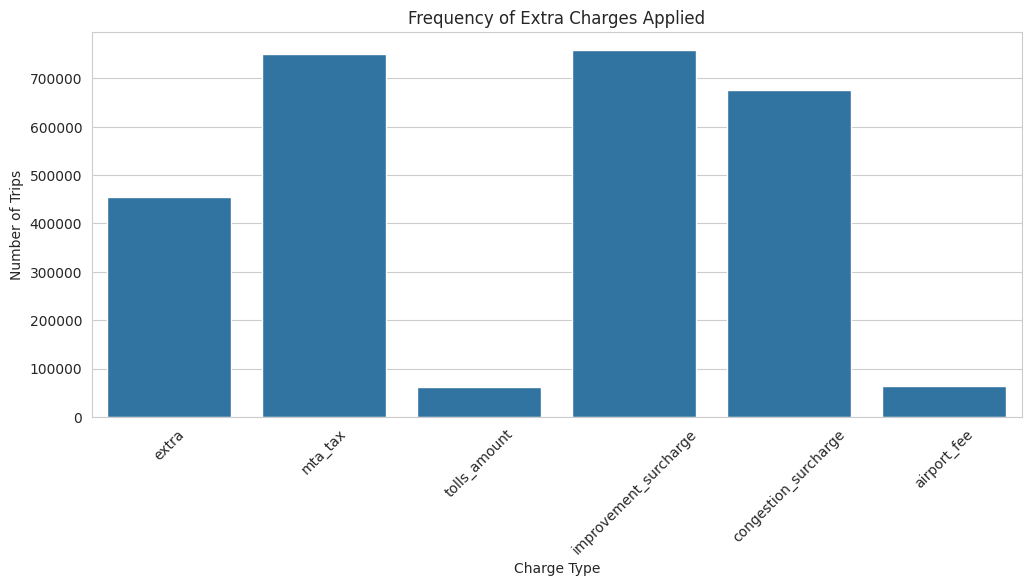

In [181]:
# Task 40: Extra Charge Analysis

extra_charge_summary = pd.DataFrame({
    "charge_type": [
        "extra",
        "mta_tax",
        "tolls_amount",
        "improvement_surcharge",
        "congestion_surcharge",
        "airport_fee"
    ],
    "applied_trip_count": [
        (df["extra"] > 0).sum(),
        (df["mta_tax"] > 0).sum(),
        (df["tolls_amount"] > 0).sum(),
        (df["improvement_surcharge"] > 0).sum(),
        (df["congestion_surcharge"] > 0).sum(),
        (df["airport_fee"] > 0).sum()
    ]
})

extra_charge_summary

plt.figure(figsize=(12,5))

sns.barplot(
    data=extra_charge_summary,
    x="charge_type",
    y="applied_trip_count"
)

plt.xticks(rotation=45)
plt.title("Frequency of Extra Charges Applied")
plt.xlabel("Charge Type")
plt.ylabel("Number of Trips")
plt.show()

# Final Recommendations:
# 1. Increase driver availability during evening peak hours.
# 2. Prioritize cab positioning around Manhattan, JFK Airport, LaGuardia Airport, Penn Station, and Times Square.
# 3. Use demand forecasting by hour, day, and zone to reduce driver idle time.
# 4. Encourage credit card and digital payments because they generate higher recorded tip revenue.
# 5. Monitor slow routes and high-congestion corridors to improve dispatching efficiency.
# 6. Use fare-per-mile and distance-tier analysis to guide pricing strategy.
# 7. Maintain strong cab availability for short-distance urban trips, which form the majority of demand.

In [182]:
# final Save

df.to_parquet(
    "output/final_nyc_taxi_analysis.parquet",
    index=False
)

print("Project Completed Successfully")

Project Completed Successfully
